# Machine Learning — Prédiction de l'état énergétique du CubeSat TSURU

Ce notebook vise à prédire la tension batterie du CubeSat TSURU à partir des données de télémétrie, de météo spatiale et des paramètres orbitaux.

Deux modèles sont testés :
- Random Forest Regressor
- Gradient Boosting Regressor

L'objectif est de comparer leurs performances et de conserver le modèle le plus pertinent pour le dashboard Power BI.

In [2]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Chargement des données

Les données sont récupérées depuis la table fact enrichie du Data Warehouse SatelliteDW.

In [3]:
server = "localhost"  
database = "SatelliteDW"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

query = """
SELECT
    f.measurement_datetime,

    f.battery_voltage_V,
    f.battery_current_mA,
    f.battery_temperature_C,
    f.battery_power_W,

    f.solar_power_W,
    f.consumption_W,
    f.energy_balance_W,

    f.vpx_mV,
    f.vpy_mV,
    f.vpz_mV,
    f.vmx_mV,
    f.vmz_mV,

    f.ipx_mA,
    f.ipy_mA,
    f.ipz_mA,
    f.imx_mA,
    f.imz_mA,

    f.tpx_C,
    f.tpy_C,
    f.tpz_C,
    f.tmx_C,
    f.tmz_C,

    f.latitude,
    f.longitude,
    f.altitude_km,

    w.kp_index,
    w.ap,
    w.sn,
    w.fobs,
    w.geomagnetic_level

FROM BIRDS_Fact_eps_telemetry f
LEFT JOIN BIRDS_Dim_weather w
    ON f.spaceweather_id = w.spaceweather_id
WHERE f.battery_voltage_V IS NOT NULL
"""

df = pd.read_sql(query, engine)

df.head()

,measurement_datetime,battery_voltage_V,battery_current_mA,battery_temperature_C,battery_power_W,solar_power_W,consumption_W,energy_balance_W,vpx_mV,vpy_mV,...,tmx_C,tmz_C,latitude,longitude,altitude_km,kp_index,ap,sn,fobs,geomagnetic_level
0,2021-03-28 00:00:00.000,4.1,280.91,10.26,1.151731,0.036493,0.0,0.036493,1272.89,1326.31,...,-0.81,-3.91,-47.623622,-169.718087,470.855164,3.333,18.0,12.0,73.9,unsettled
1,2021-03-28 00:00:11.300,4.1,292.62,10.26,1.199742,0.030519,0.0,0.030519,1272.89,1326.31,...,-1.25,-4.02,-47.905790,-168.778485,470.903206,3.333,18.0,12.0,73.9,unsettled
2,2021-03-28 00:00:22.600,4.1,351.19,10.26,1.439879,0.030519,0.0,0.030519,1272.89,1326.31,...,-1.58,-4.36,-48.179387,-167.828274,470.948018,3.333,18.0,12.0,73.9,unsettled
3,2021-03-28 00:00:33.900,4.1,307.26,10.26,1.259766,0.042482,0.0,0.042482,1272.89,1326.31,...,-2.03,-4.69,-48.444242,-166.867575,470.989550,3.333,18.0,12.0,73.9,unsettled
4,2021-03-28 00:00:45.200,4.1,257.48,10.26,1.055668,0.030512,0.0,0.030512,1271.37,1326.31,...,-2.36,-5.02,-48.700181,-165.896528,471.027759,3.333,18.0,12.0,73.9,unsettled


# Vérification des données

On vérifie la taille du dataset, les colonnes disponibles et les valeurs manquantes.

In [4]:
print(df.shape)
df.info()

(23266, 31)
<class 'pandas.DataFrame'>
RangeIndex: 23266 entries, 0 to 23265
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   measurement_datetime   23266 non-null  datetime64[us]
 1   battery_voltage_V      23266 non-null  float64       
 2   battery_current_mA     23266 non-null  float64       
 3   battery_temperature_C  23266 non-null  float64       
 4   battery_power_W        23266 non-null  float64       
 5   solar_power_W          23266 non-null  float64       
 6   consumption_W          23266 non-null  float64       
 7   energy_balance_W       23266 non-null  float64       
 8   vpx_mV                 23266 non-null  float64       
 9   vpy_mV                 23266 non-null  float64       
 10  vpz_mV                 23266 non-null  float64       
 11  vmx_mV                 23266 non-null  float64       
 12  vmz_mV                 23266 non-null  float64       
 13  

In [5]:
df.isna().sum().sort_values(ascending=False).head(20)

measurement_datetime     0
battery_voltage_V        0
battery_current_mA       0
battery_temperature_C    0
battery_power_W          0
solar_power_W            0
consumption_W            0
energy_balance_W         0
vpx_mV                   0
vpy_mV                   0
vpz_mV                   0
vmx_mV                   0
vmz_mV                   0
ipx_mA                   0
ipy_mA                   0
ipz_mA                   0
imx_mA                   0
imz_mA                   0
tpx_C                    0
tpy_C                    0
dtype: int64

# Nettoyage

Les valeurs de tension batterie nulles ou égales à zéro sont retirées car elles correspondent probablement à des valeurs manquantes ou invalides.

In [6]:
df = df[df["battery_voltage_V"] > 0].copy()

df = df.dropna(subset=[
    "battery_voltage_V",
    "battery_current_mA",
    "battery_temperature_C",
    "solar_power_W",
    "altitude_km"
])

print(df.shape)

(23259, 31)


# Création de variables temporelles

Le comportement énergétique d'un satellite dépend fortement du temps et des cycles orbitaux.  
On extrait donc l'heure, le mois et le jour de l'année à partir du timestamp.

In [7]:
df["measurement_datetime"] = pd.to_datetime(df["measurement_datetime"])

df["hour"] = df["measurement_datetime"].dt.hour
df["month"] = df["measurement_datetime"].dt.month
df["dayofyear"] = df["measurement_datetime"].dt.dayofyear

df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

df.head()

,measurement_datetime,battery_voltage_V,battery_current_mA,battery_temperature_C,battery_power_W,solar_power_W,consumption_W,energy_balance_W,vpx_mV,vpy_mV,...,kp_index,ap,sn,fobs,geomagnetic_level,hour,month,dayofyear,sin_hour,cos_hour
0,2021-03-28 00:00:00.000,4.1,280.91,10.26,1.151731,0.036493,0.0,0.036493,1272.89,1326.31,...,3.333,18.0,12.0,73.9,unsettled,0,3,87,0.0,1.0
1,2021-03-28 00:00:11.300,4.1,292.62,10.26,1.199742,0.030519,0.0,0.030519,1272.89,1326.31,...,3.333,18.0,12.0,73.9,unsettled,0,3,87,0.0,1.0
2,2021-03-28 00:00:22.600,4.1,351.19,10.26,1.439879,0.030519,0.0,0.030519,1272.89,1326.31,...,3.333,18.0,12.0,73.9,unsettled,0,3,87,0.0,1.0
3,2021-03-28 00:00:33.900,4.1,307.26,10.26,1.259766,0.042482,0.0,0.042482,1272.89,1326.31,...,3.333,18.0,12.0,73.9,unsettled,0,3,87,0.0,1.0
4,2021-03-28 00:00:45.200,4.1,257.48,10.26,1.055668,0.030512,0.0,0.030512,1271.37,1326.31,...,3.333,18.0,12.0,73.9,unsettled,0,3,87,0.0,1.0


# Encodage des variables catégorielles

La variable geomagnetic_level est textuelle.  
Elle est transformée en variables numériques grâce au one-hot encoding.

In [8]:
df_ml = pd.get_dummies(
    df,
    columns=["geomagnetic_level"],
    drop_first=True
)

df_ml.head()

,measurement_datetime,battery_voltage_V,battery_current_mA,battery_temperature_C,battery_power_W,solar_power_W,consumption_W,energy_balance_W,vpx_mV,vpy_mV,...,kp_index,ap,sn,fobs,hour,month,dayofyear,sin_hour,cos_hour,geomagnetic_level_unsettled
0,2021-03-28 00:00:00.000,4.1,280.91,10.26,1.151731,0.036493,0.0,0.036493,1272.89,1326.31,...,3.333,18.0,12.0,73.9,0,3,87,0.0,1.0,True
1,2021-03-28 00:00:11.300,4.1,292.62,10.26,1.199742,0.030519,0.0,0.030519,1272.89,1326.31,...,3.333,18.0,12.0,73.9,0,3,87,0.0,1.0,True
2,2021-03-28 00:00:22.600,4.1,351.19,10.26,1.439879,0.030519,0.0,0.030519,1272.89,1326.31,...,3.333,18.0,12.0,73.9,0,3,87,0.0,1.0,True
3,2021-03-28 00:00:33.900,4.1,307.26,10.26,1.259766,0.042482,0.0,0.042482,1272.89,1326.31,...,3.333,18.0,12.0,73.9,0,3,87,0.0,1.0,True
4,2021-03-28 00:00:45.200,4.1,257.48,10.26,1.055668,0.030512,0.0,0.030512,1271.37,1326.31,...,3.333,18.0,12.0,73.9,0,3,87,0.0,1.0,True


# Variable cible (target)

La variable à prédire est la tension batterie réelle mesurée à bord du satellite.

Elle est plus rigoureuse que le pourcentage batterie estimé, car elle provient directement des données BIRDS.

In [9]:
target = "battery_voltage_V"

# Variables explicatives (features)

Le modèle utilise trois familles de variables :

- télémétrie énergétique,
- météo spatiale,
- paramètres orbitaux.

In [10]:
features = [
    "battery_current_mA",
    "battery_temperature_C",
    "battery_power_W",

    "solar_power_W",
    "consumption_W",
    "energy_balance_W",

    "vpx_mV", "vpy_mV", "vpz_mV", "vmx_mV", "vmz_mV",
    "ipx_mA", "ipy_mA", "ipz_mA", "imx_mA", "imz_mA",

    "tpx_C", "tpy_C", "tpz_C", "tmx_C", "tmz_C",

    "latitude",
    "longitude",
    "altitude_km",

    "kp_index",
    "ap",
    "sn",
    "fobs",

    "hour",
    "month",
    "dayofyear",
    "sin_hour",
    "cos_hour"
]

geo_cols = [col for col in df_ml.columns if col.startswith("geomagnetic_level_")]
features = features + geo_cols

features = [col for col in features if col in df_ml.columns]

X = df_ml[features]
y = df_ml[target]

print("Nombre de variables utilisées :", len(features))
features

Nombre de variables utilisées : 34


['battery_current_mA',
 'battery_temperature_C',
 'battery_power_W',
 'solar_power_W',
 'consumption_W',
 'energy_balance_W',
 'vpx_mV',
 'vpy_mV',
 'vpz_mV',
 'vmx_mV',
 'vmz_mV',
 'ipx_mA',
 'ipy_mA',
 'ipz_mA',
 'imx_mA',
 'imz_mA',
 'tpx_C',
 'tpy_C',
 'tpz_C',
 'tmx_C',
 'tmz_C',
 'latitude',
 'longitude',
 'altitude_km',
 'kp_index',
 'ap',
 'sn',
 'fobs',
 'hour',
 'month',
 'dayofyear',
 'sin_hour',
 'cos_hour',
 'geomagnetic_level_unsettled']

# Traitement des valeurs manquantes

Les éventuelles valeurs manquantes restantes sont remplacées par la médiane de chaque colonne.

In [11]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

print(X.isna().sum().sum())

0


# Séparation des données

Le dataset est séparé en un jeu d'entraînement et un jeu de test afin d'évaluer le modèle sur des données non vues.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (18607, 34)
Test : (4652, 34)


# Modèle 1 : Random Forest Regressor

Le Random Forest combine plusieurs arbres de décision afin de produire une prédiction robuste.  
Il est adapté aux relations non linéaires entre les variables.

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [14]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

Random Forest
MAE : 0.00793742686042074
RMSE : 0.01142464800554168
R² : 0.9818216561325552


# Modèle 2 : Gradient Boosting Regressor

Le Gradient Boosting construit les arbres progressivement.  
Chaque nouvel arbre cherche à corriger les erreurs du précédent.

In [15]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [16]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE :", rmse_gb)
print("R² :", r2_gb)

Gradient Boosting
MAE : 0.009473769762725619
RMSE : 0.012468406321858966
R² : 0.9783483722803853


# Comparaison des performances

Les deux modèles sont comparés avec trois métriques :

- MAE : erreur moyenne absolue,
- RMSE : erreur quadratique moyenne,
- R² : part de la variabilité expliquée.

In [17]:
results = pd.DataFrame({
    "model": ["Random Forest", "Gradient Boosting"],
    "MAE": [mae_rf, mae_gb],
    "RMSE": [rmse_rf, rmse_gb],
    "R2": [r2_rf, r2_gb]
})

results

,model,MAE,RMSE,R2
0,Random Forest,0.007937,0.011425,0.981822
1,Gradient Boosting,0.009474,0.012468,0.978348


# Modèle 3 : XGBoost Regressor

Le modèle XGBoost (Extreme Gradient Boosting) est une méthode d'ensemble basée sur le principe du boosting.

Contrairement au Random Forest, qui construit plusieurs arbres indépendants, XGBoost construit les arbres successivement. Chaque nouvel arbre cherche à corriger les erreurs commises par les précédents.

Ce modèle est particulièrement réputé pour ses performances sur les jeux de données tabulaires et constitue aujourd'hui l'une des références en compétition de Machine Learning.

In [18]:
from xgboost import XGBRegressor

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [20]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R² :", r2_xgb)

XGBoost
MAE : 0.007106247788754852
RMSE : 0.009830298446639886
R² : 0.9865413324922223


# Modèle 4 : Extra Trees Regressor

Le modèle Extra Trees (Extremely Randomized Trees) est une variante du Random Forest.

Il repose également sur un ensemble d'arbres de décision mais introduit davantage d'aléatoire lors de la construction des arbres. Cette stratégie permet souvent d'améliorer la capacité de généralisation du modèle et de réduire le risque de surapprentissage.

Dans le contexte de la télémétrie satellite, il constitue une excellente alternative au Random Forest classique.

In [21]:
from sklearn.ensemble import ExtraTreesRegressor

In [22]:
et_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

In [23]:
mae_et = mean_absolute_error(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et = r2_score(y_test, y_pred_et)

print("Extra Trees")
print("MAE :", mae_et)
print("RMSE :", rmse_et)
print("R² :", r2_et)

Extra Trees
MAE : 0.0069177486385780095
RMSE : 0.010949161258876239
R² : 0.9833033108411621


# Comparaison des modèles

Quatre modèles de régression ont été évalués :

- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- Extra Trees Regressor

Les performances sont comparées à l'aide de trois indicateurs :

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient de détermination)

Le meilleur modèle sera retenu pour la suite de l'étude et l'intégration dans Power BI.

In [24]:
results = pd.DataFrame({
    "model": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Extra Trees"
    ],
    "MAE": [
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_et
    ],
    "RMSE": [
        rmse_rf,
        rmse_gb,
        rmse_xgb,
        rmse_et
    ],
    "R2": [
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_et
    ]
})

results.sort_values("R2", ascending=False)

,model,MAE,RMSE,R2
2,XGBoost,0.007106,0.009830,0.986541
3,Extra Trees,0.006918,0.010949,0.983303
0,Random Forest,0.007937,0.011425,0.981822
1,Gradient Boosting,0.009474,0.012468,0.978348


# Sélection du modèle final

Le modèle XGBoost obtient les meilleures performances globales :

- MAE = 0.0071 V
- RMSE = 0.0098 V
- R² = 0.9865

Cela signifie que le modèle est capable d'expliquer près de 99 % des variations observées de la tension batterie.

Il est donc retenu comme modèle final pour la suite de l'étude.

In [25]:
best_model_name = "XGBoost"
best_model = xgb_model
y_pred_best = y_pred_xgb

print("Modèle retenu :", best_model_name)

Modèle retenu : XGBoost


# Création du tableau des prédictions

On crée un tableau contenant, pour chaque observation du jeu de test :

- la tension batterie réelle ;
- la tension batterie prédite ;
- l'erreur absolue de prédiction ;
- le nom du modèle utilisé.

Ce tableau servira ensuite à créer la page Machine Learning dans Power BI.

In [26]:
df_predictions = df.loc[X_test.index].copy()

df_predictions["battery_real_V"] = y_test.values
df_predictions["battery_predicted_V"] = y_pred_best
df_predictions["absolute_error_V"] = abs(
    df_predictions["battery_real_V"] - df_predictions["battery_predicted_V"]
)

df_predictions["model_name"] = best_model_name

df_predictions[
    [
        "measurement_datetime",
        "battery_real_V",
        "battery_predicted_V",
        "absolute_error_V",
        "model_name"
    ]
].head()

,measurement_datetime,battery_real_V,battery_predicted_V,absolute_error_V,model_name
16526,2021-10-29 00:19:30,4.17,4.173194,0.003194,XGBoost
6367,2021-06-11 00:36:00,4.10,4.098844,0.001156,XGBoost
2603,2021-04-27 01:32:20,4.17,4.169371,0.000629,XGBoost
17643,2021-11-16 01:16:40,4.04,4.051610,0.011610,XGBoost
13091,2021-09-13 00:04:50,4.07,4.068354,0.001646,XGBoost


# Métriques finales du modèle retenu

Les métriques du modèle XGBoost sont isolées afin de pouvoir les afficher facilement dans Power BI.

In [27]:
final_metrics = pd.DataFrame({
    "model_name": [best_model_name],
    "MAE": [mean_absolute_error(y_test, y_pred_best)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_best))],
    "R2": [r2_score(y_test, y_pred_best)]
})

final_metrics

,model_name,MAE,RMSE,R2
0,XGBoost,0.007106,0.00983,0.986541


# Comparaison entre tension réelle et tension prédite

Ce graphique permet de visualiser la qualité des prédictions.

Si le modèle est performant, les points doivent être proches de la diagonale idéale y = x.

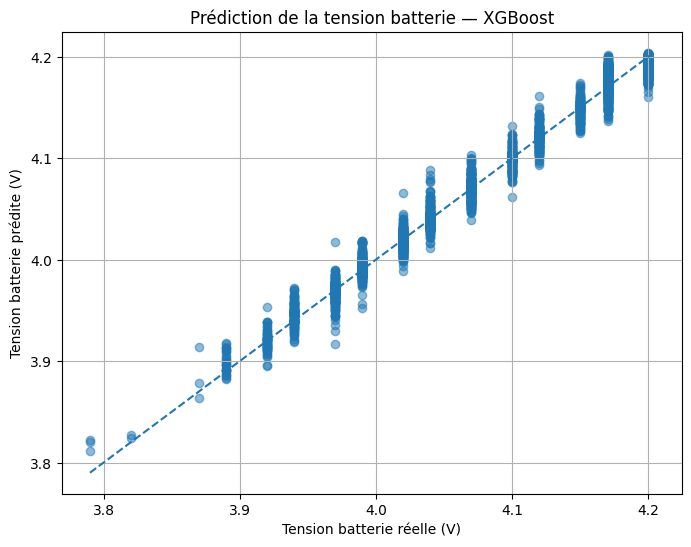

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_predictions["battery_real_V"],
    df_predictions["battery_predicted_V"],
    alpha=0.5
)

min_val = min(
    df_predictions["battery_real_V"].min(),
    df_predictions["battery_predicted_V"].min()
)

max_val = max(
    df_predictions["battery_real_V"].max(),
    df_predictions["battery_predicted_V"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Tension batterie réelle (V)")
plt.ylabel("Tension batterie prédite (V)")
plt.title("Prédiction de la tension batterie — XGBoost")
plt.grid(True)
plt.show()

# Analyse des erreurs de prédiction

L'erreur absolue permet de mesurer l'écart entre la tension réelle et la tension prédite.

Une erreur faible signifie que le modèle estime correctement l'état énergétique du satellite.

In [29]:
df_predictions["absolute_error_V"].describe()

count    4652.000000
mean        0.007106
std         0.006793
min         0.000001
25%         0.001800
50%         0.004983
75%         0.010732
max         0.053334
Name: absolute_error_V, dtype: float64

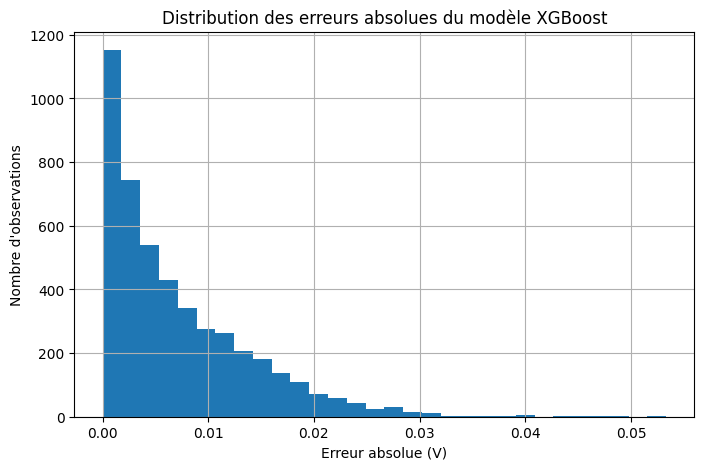

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_predictions["absolute_error_V"],
    bins=30
)

plt.xlabel("Erreur absolue (V)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution des erreurs absolues du modèle XGBoost")
plt.grid(True)
plt.show()

# Importance des variables

L'importance des variables permet d'identifier les paramètres qui contribuent le plus aux prédictions du modèle.

Cette étape permet de mieux comprendre quels facteurs énergétiques, environnementaux ou orbitaux influencent le plus la tension batterie.

In [31]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
7,vpy_mV,0.357533
6,vpx_mV,0.351348
0,battery_current_mA,0.071194
17,tpy_C,0.068625
4,consumption_W,0.023964
16,tpx_C,0.016503
19,tmx_C,0.014882
2,battery_power_W,0.014548
18,tpz_C,0.012855
10,vmz_mV,0.011878


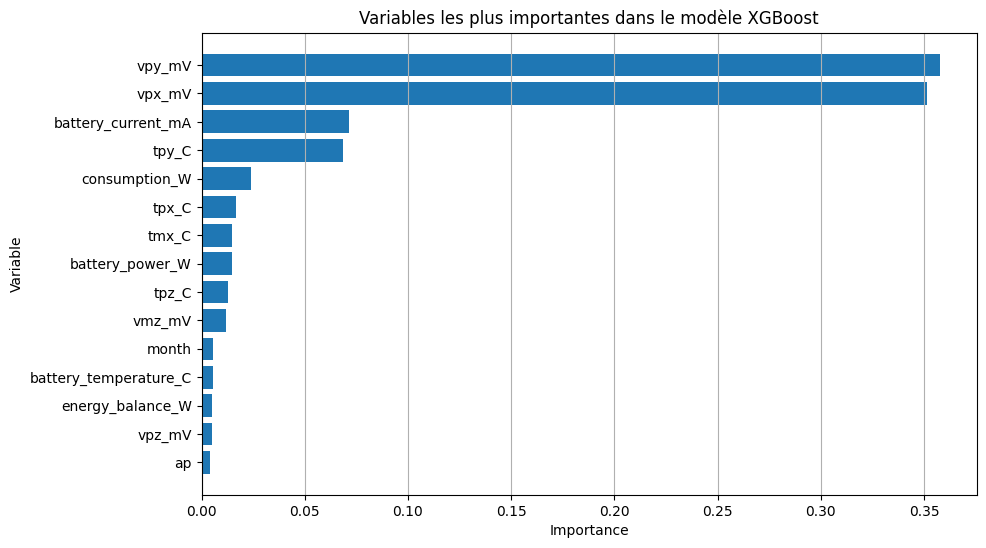

In [32]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Variables les plus importantes dans le modèle XGBoost")
plt.grid(axis="x")
plt.show()

# Export des prédictions pour Power BI

Le fichier des prédictions est exporté au format CSV afin d'être intégré dans Power BI.

Il permettra de construire :
- un graphique réel vs prédit ;
- des cartes de métriques ;
- une analyse des erreurs de prédiction.

In [33]:
df_predictions.to_csv(
    "BIRDS_ML_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Fichier BIRDS_ML_predictions.csv exporté.")

Fichier BIRDS_ML_predictions.csv exporté.


# Export des performances des modèles

Le tableau comparatif des quatre modèles est exporté afin de pouvoir être affiché dans Power BI.

In [34]:
results.to_csv(
    "BIRDS_ML_model_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Fichier BIRDS_ML_model_metrics.csv exporté.")

Fichier BIRDS_ML_model_metrics.csv exporté.


# Export des métriques finales

Les métriques du modèle retenu sont exportées séparément pour faciliter leur affichage dans des cartes Power BI.

In [35]:
final_metrics.to_csv(
    "BIRDS_ML_final_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Fichier BIRDS_ML_final_metrics.csv exporté.")

Fichier BIRDS_ML_final_metrics.csv exporté.


# Export de l'importance des variables

L'importance des variables est exportée pour construire un graphique explicatif dans Power BI.

In [36]:
feature_importance.to_csv(
    "BIRDS_ML_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Fichier BIRDS_ML_feature_importance.csv exporté.")

Fichier BIRDS_ML_feature_importance.csv exporté.


# Sauvegarde du modèle final

Le modèle XGBoost est sauvegardé afin de pouvoir être réutilisé ultérieurement sans devoir être réentraîné.

In [37]:
import joblib

joblib.dump(
    best_model,
    "BIRDS_XGBoost_model.pkl"
)

print("Modèle XGBoost sauvegardé.")

Modèle XGBoost sauvegardé.


# Conclusion

Quatre modèles de régression ont été testés pour prédire la tension batterie du CubeSat TSURU à partir des données de télémétrie, de météo spatiale et des paramètres orbitaux.

Le modèle XGBoost obtient les meilleures performances globales avec un R² de 0,9865, une MAE de 0,0071 V et une RMSE de 0,0098 V.

Ces résultats montrent que l'état énergétique du satellite peut être estimé avec une grande précision à partir des données disponibles.

L'approche Machine Learning permet ainsi de compléter l'analyse descriptive du dashboard en ajoutant une dimension prédictive au projet E.C.L.I.P.S.E.

In [41]:

df_predictions.to_sql(
    "BIRDS_ML_predictions",
    engine,
    if_exists="replace",
    index=False
)

results.to_sql(
    "BIRDS_ML_model_metrics",
    engine,
    if_exists="replace",
    index=False
)

final_metrics.to_sql(
    "BIRDS_ML_final_metrics",
    engine,
    if_exists="replace",
    index=False
)

feature_importance.to_sql(
    "BIRDS_ML_feature_importance",
    engine,
    if_exists="replace",
    index=False
)

print("Exports Machine Learning vers SQL Server terminés.")

Exports Machine Learning vers SQL Server terminés.


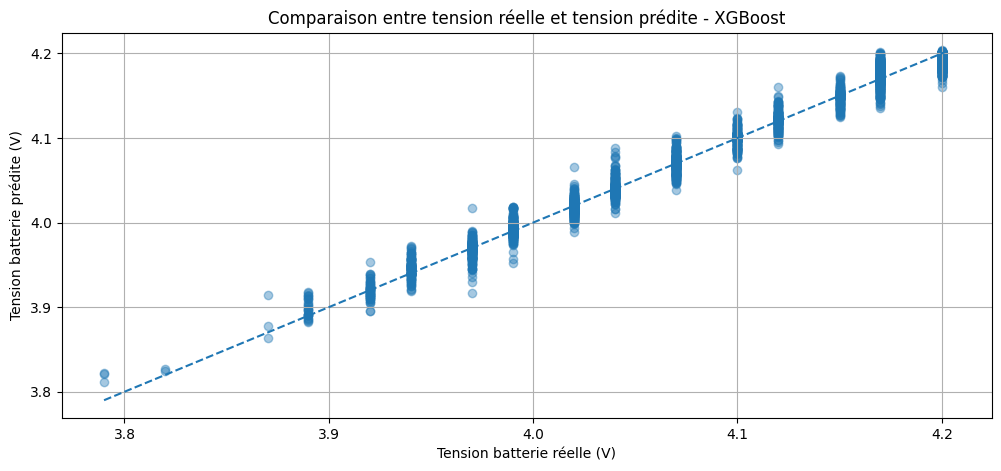

In [30]:
plt.figure(figsize=(12, 5))

plt.scatter(
    df_predictions["battery_real_V"],
    df_predictions["battery_predicted_V"],
    alpha=0.4
)

min_val = min(df_predictions["battery_real_V"].min(), df_predictions["battery_predicted_V"].min())
max_val = max(df_predictions["battery_real_V"].max(), df_predictions["battery_predicted_V"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tension batterie réelle (V)")
plt.ylabel("Tension batterie prédite (V)")
plt.title("Comparaison entre tension réelle et tension prédite - XGBoost")
plt.grid(True)

plt.savefig("ML_real_vs_predicted_wide.png", dpi=300, bbox_inches="tight")
plt.show()

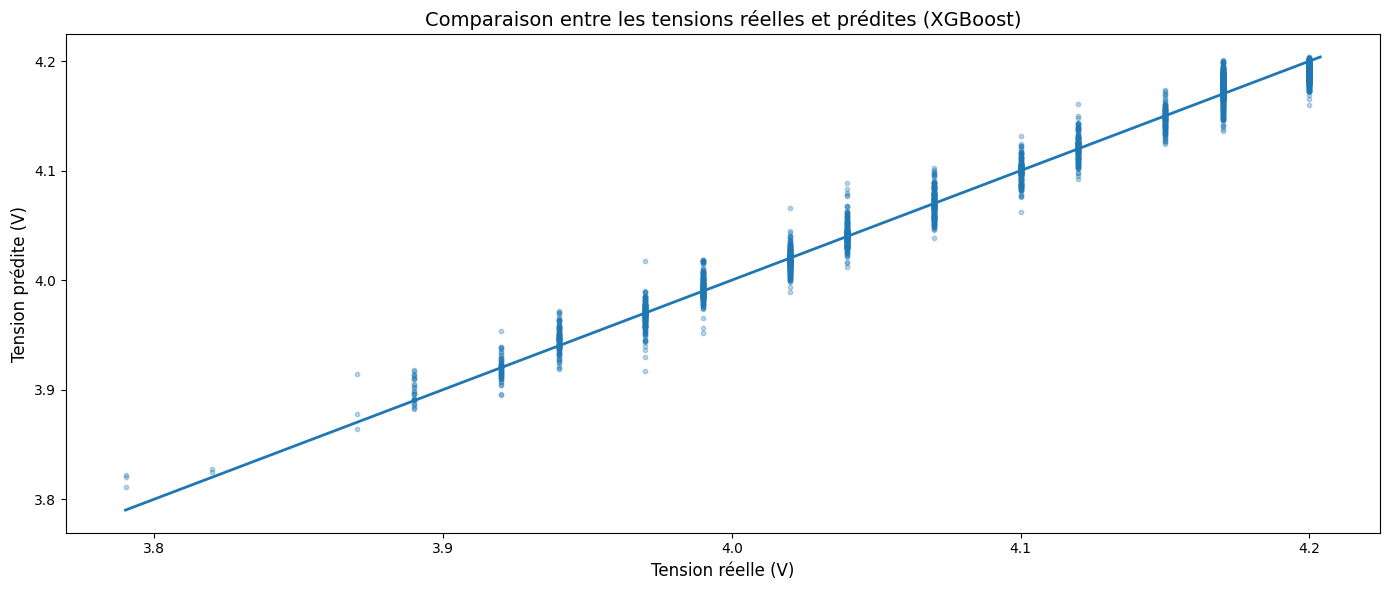

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

plt.scatter(
    df_predictions["battery_real_V"],
    df_predictions["battery_predicted_V"],
    alpha=0.3,
    s=10
)

min_val = min(
    df_predictions["battery_real_V"].min(),
    df_predictions["battery_predicted_V"].min()
)

max_val = max(
    df_predictions["battery_real_V"].max(),
    df_predictions["battery_predicted_V"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Tension réelle (V)", fontsize=12)
plt.ylabel("Tension prédite (V)", fontsize=12)
plt.title(
    "Comparaison entre les tensions réelles et prédites (XGBoost)",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "ML_real_vs_predicted_dashboard.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()